<a href="https://colab.research.google.com/github/jamesemcnally/critical-listener/blob/main/source_bias_analysis_%2B_pitchfork_recommendations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# New session setup: mount Drive, load masked dataset and Nomic embeddings.

from google.colab import drive
drive.mount("/content/drive")

import numpy as np
import pandas as pd
import random
from collections import Counter, defaultdict

DRIVE_DIR = "/content/drive/MyDrive/Colab Notebooks"

df = pd.read_parquet(f"{DRIVE_DIR}/merged_dataset_masked.parquet")
print(f"Loaded: {df.shape[0]:,} reviews")
print(df["dataset"].value_counts())

embeddings_masked = np.load(f"{DRIVE_DIR}/nomic_masked_with_prefix.npy")
print(f"\nEmbeddings: {embeddings_masked.shape}")

Mounted at /content/drive
Loaded: 48,189 reviews
dataset
pitchfork           22810
resident_advisor    15318
critique_brainz     10061
Name: count, dtype: int64

Embeddings: (48189, 768)


## Source-Distribution Diagnostic

When we mix Pitchfork and Resident Advisor reviews in the candidate pool, we risk
a **register confound**: RA reviews may cluster together in the embedding space
simply because they *sound like RA reviews* (shorter, more production-focused) — not
because the albums are genuinely similar. This is the same problem as name-drop
leakage, but harder to fix.

This cell checks whether that's actually happening. For 300 random Pitchfork queries,
we retrieve the top-10 results from a combined Pitchfork + RA pool and compare the
source breakdown against the base rate (what we'd expect if source had no effect).

**Ratio ≈ 1.0** → source is not steering results; the combined pool is safe to use.  
**Ratio >> 1.0** for Pitchfork → the model is gravitating toward Pitchfork reviews
above chance, and source register is a confound we need to address before proceeding.


In [ ]:
# Source-distribution diagnostic: do Pitchfork queries over-retrieve Pitchfork candidates?
# Compares observed source distribution in top-10 results against the base rate
# of each source in the candidate pool. Ratio > 1.0 flags a register confound.

random.seed(42)
N_QUERIES = 300
TOP_K     = 10

# Build candidate pool: Pitchfork + RA only
pf_mask   = (df["dataset"] == "pitchfork").values
ra_mask   = (df["dataset"] == "resident_advisor").values
pool_mask = pf_mask | ra_mask
pool_idx  = np.where(pool_mask)[0].tolist()

# Query sample: unique Pitchfork albums (one row per album)
pf_unique = (
    df[df["dataset"] == "pitchfork"]
    .drop_duplicates(subset=["artist_norm", "album_norm"])
    .index.tolist()
)
query_sample = random.sample(pf_unique, min(N_QUERIES, len(pf_unique)))

# Base rates: fraction of each source in the candidate pool
pool_sources  = df.loc[pool_idx, "dataset"].values
base_rate     = {src: (pool_sources == src).sum() / len(pool_idx)
                 for src in ["pitchfork", "resident_advisor"]}

# Pre-extract arrays and lookup structures
_artist_norm = df["artist_norm"].values
_album_norm  = df["album_norm"].values
_datasets    = df["dataset"].values

album_to_idx     = defaultdict(list)
for i in range(len(df)):
    album_to_idx[(_artist_norm[i], _album_norm[i])].append(i)

global_to_pool_pos = {cidx: j for j, cidx in enumerate(pool_idx)}
pool_emb           = embeddings_masked[pool_idx]   # (n_pool, 768) — computed once

# Run diagnostic
source_counts     = Counter()
scores_by_source  = defaultdict(list)

for q in query_sample:
    sim_row = (pool_emb @ embeddings_masked[q]).copy()

    # Mask out same album (cross-source copies)
    exclude = set(album_to_idx[(_artist_norm[q], _album_norm[q])])
    exclude_pos = [global_to_pool_pos[g] for g in exclude if g in global_to_pool_pos]
    if exclude_pos:
        sim_row[exclude_pos] = -np.inf

    top_pos = np.argpartition(sim_row, -TOP_K)[-TOP_K:]
    top_pos = top_pos[np.argsort(sim_row[top_pos])[::-1]]

    for pos in top_pos:
        src = _datasets[pool_idx[pos]]
        source_counts[src] += 1
        scores_by_source[src].append(float(sim_row[pos]))

# Report
total = sum(source_counts.values())
print(f"Top-{TOP_K} source distribution — {N_QUERIES} Pitchfork queries, "
      f"Pitchfork+RA candidate pool\n")
print(f"{'Source':<24} {'Count':>6} {'Observed':>10} {'Base rate':>10} {'Ratio':>8}")
print("─" * 62)
for src in ["pitchfork", "resident_advisor"]:
    obs   = source_counts[src] / total
    ratio = obs / base_rate[src]
    print(f"{src:<24} {source_counts[src]:>6,}   {obs*100:>7.1f}%   "
          f"{base_rate[src]*100:>7.1f}%   {ratio:>6.2f}x")

print(f"\nMean similarity score by source:")
for src in ["pitchfork", "resident_advisor"]:
    sc = scores_by_source[src]
    if sc:
        print(f"  {src}: {np.mean(sc):.4f}  (n={len(sc):,})")

print(f"\nInterpretation:")
print(f"  Ratio ~1.0 → source is not confounding results — safe to use combined pool")
print(f"  Ratio >> 1.0 for pitchfork → register is steering similarity, not just album content")


Top-10 source distribution — 300 Pitchfork queries, Pitchfork+RA candidate pool

Source                    Count   Observed  Base rate    Ratio
──────────────────────────────────────────────────────────────
pitchfork                 2,688      89.6%      59.8%     1.50x
resident_advisor            312      10.4%      40.2%     0.26x

Mean similarity score by source:
  pitchfork: 0.8204  (n=2,688)
  resident_advisor: 0.8173  (n=312)

Interpretation:
  Ratio ~1.0 → source is not confounding results — safe to use combined pool
  Ratio >> 1.0 for pitchfork → register is steering similarity, not just album content


In [ ]:
# Stratified source-distribution diagnostic: restricts queries to Pitchfork
# electronic/experimental albums — the only genre zone where RA has candidates
# and register confounding can be separated from genre breadth.

import numpy as np
import pandas as pd
import random
from collections import Counter, defaultdict

random.seed(42)
N_QUERIES = 300
TOP_K     = 10

# Build candidate pool: Pitchfork + RA only
pf_mask   = (df["dataset"] == "pitchfork").values
ra_mask   = (df["dataset"] == "resident_advisor").values
pool_mask = pf_mask | ra_mask
pool_idx  = np.where(pool_mask)[0].tolist()

# Base rates
pool_sources = df.loc[pool_idx, "dataset"].values
base_rate    = {src: (pool_sources == src).sum() / len(pool_idx)
                for src in ["pitchfork", "resident_advisor"]}

# Query sample: Pitchfork electronic/experimental albums only
ELECTRONIC_GENRES = [
    "electronic", "experimental", "ambient", "dance", "techno",
    "house", "club", "noise", "idm", "electronica"
]

def is_electronic(genre_val):
    if pd.isna(genre_val):
        return False
    return any(tag in genre_val.lower() for tag in ELECTRONIC_GENRES)

pf_electronic = (
    df[
        (df["dataset"] == "pitchfork") &
        (df["genre"].apply(is_electronic))
    ]
    .drop_duplicates(subset=["artist_norm", "album_norm"])
    .index.tolist()
)
query_sample = random.sample(pf_electronic, min(N_QUERIES, len(pf_electronic)))
print(f"Electronic Pitchfork albums available: {len(pf_electronic):,}")
print(f"Query sample size: {len(query_sample)}\n")

# Pre-extract arrays and lookup structures
_artist_norm = df["artist_norm"].values
_album_norm  = df["album_norm"].values
_datasets    = df["dataset"].values

album_to_idx = defaultdict(list)
for i in range(len(df)):
    album_to_idx[(_artist_norm[i], _album_norm[i])].append(i)

global_to_pool_pos = {cidx: j for j, cidx in enumerate(pool_idx)}
pool_emb           = embeddings_masked[pool_idx]

# Run diagnostic
source_counts    = Counter()
scores_by_source = defaultdict(list)

for q in query_sample:
    sim_row = (pool_emb @ embeddings_masked[q]).copy()

    exclude     = set(album_to_idx[(_artist_norm[q], _album_norm[q])])
    exclude_pos = [global_to_pool_pos[g] for g in exclude if g in global_to_pool_pos]
    if exclude_pos:
        sim_row[exclude_pos] = -np.inf

    top_pos = np.argpartition(sim_row, -TOP_K)[-TOP_K:]
    top_pos = top_pos[np.argsort(sim_row[top_pos])[::-1]]

    for pos in top_pos:
        src = _datasets[pool_idx[pos]]
        source_counts[src] += 1
        scores_by_source[src].append(float(sim_row[pos]))

# Report
total = sum(source_counts.values())
print(f"Top-{TOP_K} source distribution — {N_QUERIES} electronic Pitchfork queries, "
      f"Pitchfork+RA candidate pool\n")
print(f"{'Source':<24} {'Count':>6} {'Observed':>10} {'Base rate':>10} {'Ratio':>8}")
print("─" * 62)
for src in ["pitchfork", "resident_advisor"]:
    obs   = source_counts[src] / total
    ratio = obs / base_rate[src]
    print(f"{src:<24} {source_counts[src]:>6,}   {obs*100:>7.1f}%   "
          f"{base_rate[src]*100:>7.1f}%   {ratio:>6.2f}x")

print(f"\nMean similarity score by source:")
for src in ["pitchfork", "resident_advisor"]:
    sc = scores_by_source[src]
    if sc:
        print(f"  {src}: {np.mean(sc):.4f}  (n={len(sc):,})")

print(f"\nInterpretation:")
print(f"  Ratio ~1.0 → genre breadth explains the earlier result; combined pool is safe")
print(f"  Ratio >> 1.0 → register confound is real even within matched genres")


Electronic Pitchfork albums available: 6,433
Query sample size: 300



NameError: name 'embeddings_masked' is not defined

## What the Diagnostics Told Us

We tested whether mixing Pitchfork and Resident Advisor reviews in the candidate pool
would produce fair recommendations. The short answer: no — at least not yet.

Even when we restricted our test to electronic music (the genre RA specializes in),
Pitchfork results appeared 35% more often than their share of the pool would predict,
while RA results appeared at less than half their expected rate. The surprising part:
when RA results *did* appear, they actually scored slightly *higher* on average than
Pitchfork results. RA isn't losing because it's a worse match — it's losing because
there are so many Pitchfork reviews that one always scores just slightly higher,
crowding RA out. That's a publication-style bias, not a quality signal.

Two factors drive this: (1) Pitchfork covers many genres RA doesn't, so non-electronic
queries can only return Pitchfork results by definition; and (2) even within electronic
music, the model gives a small but consistent edge to same-source reviews, likely
because they share writing style, length, and vocabulary.

## What We're Doing Next

We now run the recommender on **Pitchfork only** — both the query albums and the
candidate pool. This isn't a limitation; it's the principled choice given what the
diagnostic showed. It gives us a clean, unconfounded baseline dataset: one consistent
critical voice, broad genre coverage, and recommendations driven by language and
themes rather than publication style.

This dataset will serve as the foundation for our comparison against Spotify-style
recommendations.


In [ ]:
# Pitchfork-only batch recommender: generates top-10 recommendations for every
# Pitchfork album using only other Pitchfork albums as candidates.
# Saves one row per (query album, recommended album) pair to Drive.

import numpy as np
import pandas as pd
import time
from collections import defaultdict

TOP_K      = 10
BATCH_SIZE = 1000
SAVE_PATH  = "/content/drive/MyDrive/Colab Notebooks/recommendations_pitchfork_only.parquet"

# Pitchfork-only pool: both queries and candidates
pf_mask  = (df["dataset"] == "pitchfork").values
pool_idx = np.where(pf_mask)[0].tolist()

# Pre-extract columns as arrays for fast per-row access
_review_ids  = df["review_id"].values
_artists     = df["artist"].values
_albums      = df["album"].values
_datasets    = df["dataset"].values
_artist_norm = df["artist_norm"].values
_album_norm  = df["album_norm"].values

# Map (artist_norm, album_norm) → all row indices (for same-album masking)
album_to_idx = defaultdict(list)
for i in range(len(df)):
    album_to_idx[(_artist_norm[i], _album_norm[i])].append(i)

# Map (artist_norm) → all row indices (for same-artist masking)
artist_to_idx = defaultdict(list)
for i in range(len(df)):
    artist_to_idx[_artist_norm[i]].append(i)

# Map global index → position in pool_idx (for fast exclusion)
global_to_pool_pos = {cidx: j for j, cidx in enumerate(pool_idx)}

# Pre-extract candidate embeddings once
pool_emb  = embeddings_masked[pool_idx]   # (n_pf, 768)
n_queries = len(pool_idx)

print(f"Query albums:    {n_queries:,}")
print(f"Candidate pool:  {len(pool_idx):,}")
print(f"Top-k:           {TOP_K}")

# Batch generation
rows    = []
t_start = time.time()

for batch_start in range(0, n_queries, BATCH_SIZE):
    batch_q_idx = pool_idx[batch_start : batch_start + BATCH_SIZE]

    # (batch_size, 768) @ (768, n_pool) → (batch_size, n_pool)
    batch_emb  = embeddings_masked[batch_q_idx]
    batch_sims = batch_emb @ pool_emb.T

    for i, q in enumerate(batch_q_idx):
        sim_row = batch_sims[i].copy()

        # Exclude same album (all sources) and same artist
        exclude = set(album_to_idx[(_artist_norm[q], _album_norm[q])])
        exclude.update(artist_to_idx[_artist_norm[q]])
        exclude_pos = [global_to_pool_pos[g] for g in exclude if g in global_to_pool_pos]
        if exclude_pos:
            sim_row[exclude_pos] = -np.inf

        top_pos = np.argpartition(sim_row, -TOP_K)[-TOP_K:]
        top_pos = top_pos[np.argsort(sim_row[top_pos])[::-1]]

        for rank, pos in enumerate(top_pos, 1):
            rec = pool_idx[pos]
            rows.append({
                "query_review_id": _review_ids[q],
                "query_artist":    _artists[q],
                "query_album":     _albums[q],
                "rank":            rank,
                "rec_review_id":   _review_ids[rec],
                "rec_artist":      _artists[rec],
                "rec_album":       _albums[rec],
                "rec_score":       round(float(sim_row[pos]), 4),
            })

    done    = min(batch_start + BATCH_SIZE, n_queries)
    elapsed = time.time() - t_start
    eta     = (n_queries - done) / (done / elapsed) if done > 0 else 0
    if done % 5000 == 0 or done == n_queries:
        print(f"  {done:,}/{n_queries:,}  |  {elapsed:.0f}s elapsed  |  ETA ~{eta:.0f}s")

df_recs = pd.DataFrame(rows)
df_recs.to_parquet(SAVE_PATH, index=False)

elapsed = time.time() - t_start
print(f"\nDone in {elapsed:.1f}s")
print(f"Saved {len(df_recs):,} rows → {SAVE_PATH}")
print(f"\nUnique query albums: {df_recs['query_album'].nunique():,}")
print(f"Unique rec albums:   {df_recs['rec_album'].nunique():,}")
print(f"\nSample output:")
print(df_recs.head(10).to_string(index=False))

Query albums:    22,810
Candidate pool:  22,810
Top-k:           10
  5,000/22,810  |  1s elapsed  |  ETA ~5s
  10,000/22,810  |  3s elapsed  |  ETA ~3s
  15,000/22,810  |  4s elapsed  |  ETA ~2s
  20,000/22,810  |  5s elapsed  |  ETA ~1s
  22,810/22,810  |  6s elapsed  |  ETA ~0s

Done in 6.2s
Saved 228,100 rows → /content/drive/MyDrive/Colab Notebooks/recommendations_pitchfork_only.parquet

Unique query albums: 22,032
Unique rec albums:   19,827

Sample output:
query_review_id query_artist query_album  rank rec_review_id          rec_artist                                        rec_album  rec_score
           9232       Avarus   Vesikansi     1         18682          Paavoharju Joko sinä tulet tänne alas tai minä nousen sinne     0.8661
           9232       Avarus   Vesikansi     2         19351 Kemialliset Ystävät                            Alas Rattoisaa Virtaa     0.8378
           9232       Avarus   Vesikansi     3         21610      Oranssi Pazuzu                             

## EDA: Recommendation Dataset

Before using this dataset, we need to understand its shape and
any structural biases it may contain. This EDA covers seven questions:

1. **Score distribution** — what do the similarity scores look like, and how
   sharply do they drop from rank 1 to rank 10?

2. **Hubness** — are a small number of albums dominating the recommendations,
   appearing in everyone's top-10 regardless of the query?

3. **Coverage** — what share of Pitchfork albums are ever recommended at all?
   What characterizes the albums that are never surfaced?

4. **Rating bias** — do higher-similarity recommendations tend to be
   better-reviewed albums?

5. **Cross-genre recommendation rate** — for each query album's genre, what
   genres do its recommendations come from? This directly tests the bridging
   capital thesis: is the system surfacing cross-genre connections, or just
   recommending within the same genre?

6. **Hub album spot-check** — the top hub albums (appearing hundreds of times
   as recommendations) are mostly obscure records, not canonical ones. Are their
   reviews genuinely rich, or generically written in a way that matches everything?

7. **Reciprocity** — if album A recommends album B, does B recommend A? High
   reciprocity suggests tight mutual clusters; low reciprocity suggests the
   recommendations are more asymmetric and discovery-oriented.


In [ ]:
# Restart cell: load only columns needed for EDA — avoids loading full review text.

from google.colab import drive
drive.mount("/content/drive")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

DRIVE_DIR = "/content/drive/MyDrive/Colab Notebooks"

df = pd.read_parquet(
    f"{DRIVE_DIR}/merged_dataset_masked.parquet",
    columns=["review_id", "dataset", "rating", "genre"]
)
df_recs = pd.read_parquet(f"{DRIVE_DIR}/recommendations_pitchfork_only.parquet")

print(f"df:      {df.shape}")
print(f"df_recs: {len(df_recs):,} rows, {df_recs['query_album'].nunique():,} unique query albums")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
df:      (48189, 4)
df_recs: 228,100 rows, 22,032 unique query albums


SCORE DISTRIBUTION
  Mean:   0.7994
  Median: 0.7992
  Std:    0.0303
  Min:    0.6828
  Max:    0.9695

  Mean score by rank:
    Rank  1: 0.8197  (±0.0308)
    Rank  2: 0.8093  (±0.0292)
    Rank  3: 0.8039  (±0.0288)
    Rank  4: 0.8004  (±0.0286)
    Rank  5: 0.7977  (±0.0286)
    Rank  6: 0.7956  (±0.0286)
    Rank  7: 0.7938  (±0.0287)
    Rank  8: 0.7924  (±0.0287)
    Rank  9: 0.7911  (±0.0287)
    Rank 10: 0.7899  (±0.0288)


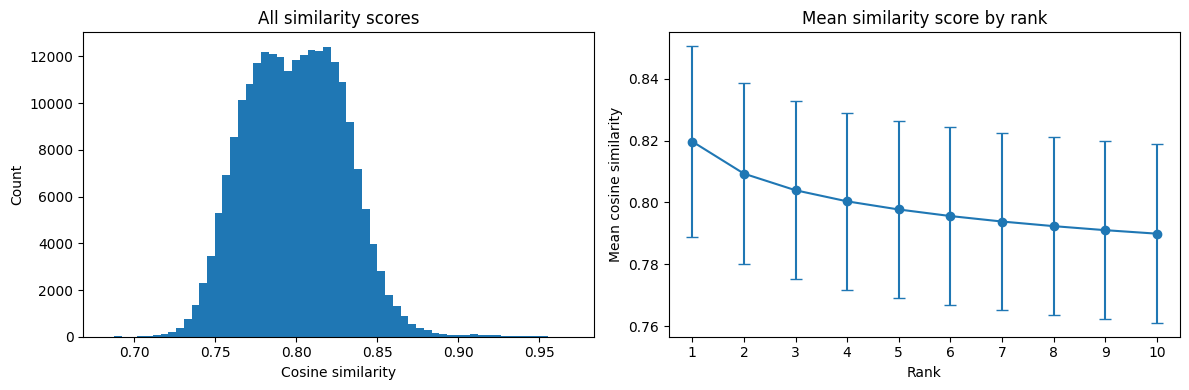

In [ ]:
# EDA Part 1: similarity score distribution across all recommendations and by rank.

scores     = df_recs["rec_score"]
rank_means = df_recs.groupby("rank")["rec_score"].agg(["mean", "std"])

print("SCORE DISTRIBUTION")
print(f"  Mean:   {scores.mean():.4f}")
print(f"  Median: {scores.median():.4f}")
print(f"  Std:    {scores.std():.4f}")
print(f"  Min:    {scores.min():.4f}")
print(f"  Max:    {scores.max():.4f}")
print(f"\n  Mean score by rank:")
for r, row in rank_means.iterrows():
    print(f"    Rank {r:>2}: {row['mean']:.4f}  (±{row['std']:.4f})")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.hist(scores, bins=60, edgecolor="none")
ax1.set_title("All similarity scores")
ax1.set_xlabel("Cosine similarity")
ax1.set_ylabel("Count")

ax2.errorbar(rank_means.index, rank_means["mean"], yerr=rank_means["std"],
             fmt="o-", capsize=4)
ax2.set_title("Mean similarity score by rank")
ax2.set_xlabel("Rank")
ax2.set_ylabel("Mean cosine similarity")
ax2.set_xticks(range(1, 11))

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Colab Notebooks/eda_1_scores.png", dpi=100)
plt.show()
plt.close()


HUBNESS

  Top 20 most-recommended albums:
  Artist                         Album                                Count   % of recs
  ────────────────────────────── ─────────────────────────────────── ──────  ──────────
  Shimmer                        And I Revel                            911      0.40%
  Post Animal                    When I Think of You in a Castle        735      0.32%
  These Are Powers               Terrific Seasons                       687      0.30%
  The Music                      The Music                              572      0.25%
  Sightings                      Amusers and Puzzlers                   467      0.20%
  Growing                        All the Way                            393      0.17%
  SW.                            The Album                              373      0.16%
  Beak>                          >>                                     345      0.15%
  Hinds                          The Prettiest Curse                    336      0.15

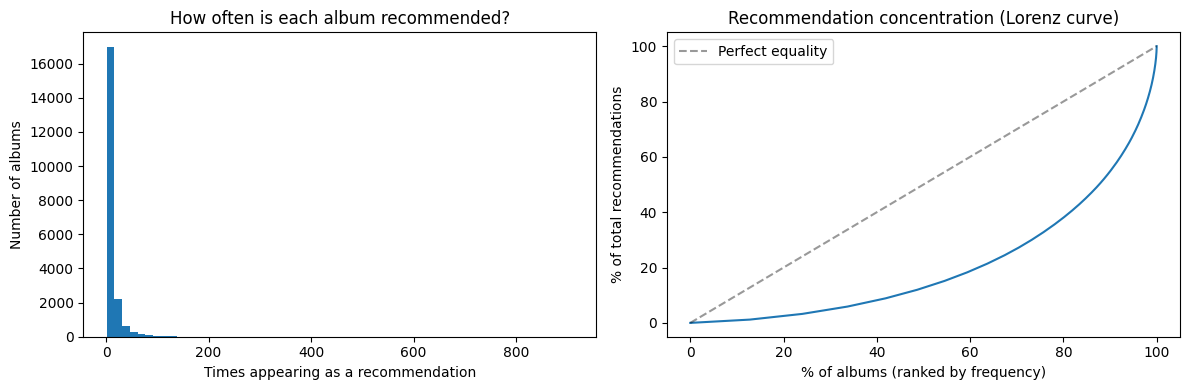

In [ ]:
# EDA Part 2: which albums dominate recommendations, and how concentrated is the distribution?

rec_counts = df_recs.groupby(["rec_artist", "rec_album"]).size().sort_values(ascending=False)
total_recs = len(df_recs)

print("HUBNESS")
print(f"\n  Top 20 most-recommended albums:")
print(f"  {'Artist':<30} {'Album':<35} {'Count':>6}  {'% of recs':>10}")
print(f"  {'─'*30} {'─'*35} {'─'*6}  {'─'*10}")
for (artist, album), count in rec_counts.head(20).items():
    print(f"  {artist[:30]:<30} {album[:35]:<35} {count:>6,}  {count/total_recs*100:>8.2f}%")

print(f"\n  Concentration:")
for n in [10, 50, 100, 500]:
    share = rec_counts.head(n).sum() / total_recs * 100
    print(f"    Top {n:>4} albums → {share:.1f}% of all recommendations")

sorted_counts = np.sort(rec_counts.values)
cumulative    = np.cumsum(sorted_counts) / sorted_counts.sum()
x_pct         = np.linspace(0, 100, len(cumulative))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.hist(rec_counts.values, bins=60, edgecolor="none")
ax1.set_title("How often is each album recommended?")
ax1.set_xlabel("Times appearing as a recommendation")
ax1.set_ylabel("Number of albums")

ax2.plot(x_pct, cumulative * 100)
ax2.plot([0, 100], [0, 100], "k--", alpha=0.4, label="Perfect equality")
ax2.set_title("Recommendation concentration (Lorenz curve)")
ax2.set_xlabel("% of albums (ranked by frequency)")
ax2.set_ylabel("% of total recommendations")
ax2.legend()

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Colab Notebooks/eda_2_hubness.png", dpi=100)
plt.show()
plt.close()


COVERAGE

  Total Pitchfork albums:  22,810
  Ever recommended:        20,998  (92.1%)
  Never recommended:       1,812  (7.9%)

  Rating comparison (0–5 scale):
    Never recommended — mean: 3.37, median: 3.50
    Ever recommended  — mean: 3.54, median: 3.65

  Genre breakdown of never-recommended albums:
  Genre                 Never rec  Total in corpus   % of genre never rec
  ──────────────────── ────────── ──────────────── ──────────────────────
  Rock                        893           10,554                  8.5%
  Electronic                  401            4,437                  9.0%
  Pop/R&B                     171            2,073                  8.2%
  Experimental                160            2,190                  7.3%
  Rap                         141            2,296                  6.1%
  Metal                        82              946                  8.7%
  Folk/Country                 71              931                  7.6%
  Jazz                         39

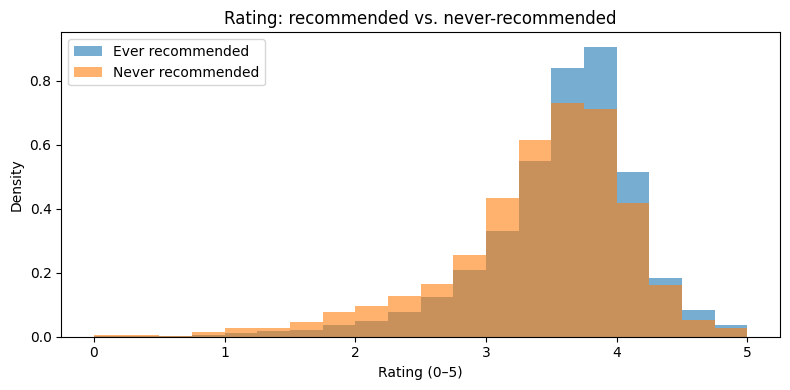

In [ ]:
# EDA Part 3: what share of Pitchfork albums are ever recommended, and what characterizes
# the ones that never appear?

pf                     = df[df["dataset"] == "pitchfork"].copy()
recommended_ids        = set(df_recs["rec_review_id"].unique())
pf["ever_recommended"] = pf["review_id"].isin(recommended_ids)

never = pf[~pf["ever_recommended"]]
ever  = pf[ pf["ever_recommended"]]

print("COVERAGE")
print(f"\n  Total Pitchfork albums:  {len(pf):,}")
print(f"  Ever recommended:        {len(ever):,}  ({len(ever)/len(pf)*100:.1f}%)")
print(f"  Never recommended:       {len(never):,}  ({len(never)/len(pf)*100:.1f}%)")
print(f"\n  Rating comparison (0–5 scale):")
print(f"    Never recommended — mean: {never['rating'].mean():.2f}, "
      f"median: {never['rating'].median():.2f}")
print(f"    Ever recommended  — mean: {ever['rating'].mean():.2f}, "
      f"median: {ever['rating'].median():.2f}")

# Genre breakdown: % of each genre that is never recommended
all_genres   = (
    pf["genre"].dropna()
    .str.split(",").explode().str.strip()
    .value_counts()
    .rename("total")
)
never_genres = (
    never["genre"].dropna()
    .str.split(",").explode().str.strip()
    .value_counts()
    .rename("never_rec")
)
genre_df = (
    pd.concat([never_genres, all_genres], axis=1)
    .dropna()
    .assign(pct_never=lambda x: x["never_rec"] / x["total"] * 100)
    .sort_values("never_rec", ascending=False)
    .head(12)
)
print(f"\n  Genre breakdown of never-recommended albums:")
print(f"  {'Genre':<20} {'Never rec':>10} {'Total in corpus':>16} {'% of genre never rec':>22}")
print(f"  {'─'*20} {'─'*10} {'─'*16} {'─'*22}")
for genre, row in genre_df.iterrows():
    print(f"  {genre:<20} {int(row['never_rec']):>10,} {int(row['total']):>16,} {row['pct_never']:>20.1f}%")

bins = np.arange(0, 5.25, 0.25)
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(ever["rating"].dropna(),  bins=bins, alpha=0.6, density=True, label="Ever recommended")
ax.hist(never["rating"].dropna(), bins=bins, alpha=0.6, density=True, label="Never recommended")
ax.set_title("Rating: recommended vs. never-recommended")
ax.set_xlabel("Rating (0–5)")
ax.set_ylabel("Density")
ax.legend()

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Colab Notebooks/eda_3_coverage.png", dpi=100)
plt.show()
plt.close()
del pf, never, ever


RATING BIAS

  Correlation (similarity score vs. rec rating): -0.0000

  Mean rec rating by rank:
    Rank  1: 3.646
    Rank  2: 3.646
    Rank  3: 3.647
    Rank  4: 3.647
    Rank  5: 3.647
    Rank  6: 3.647
    Rank  7: 3.646
    Rank  8: 3.646
    Rank  9: 3.647
    Rank 10: 3.647


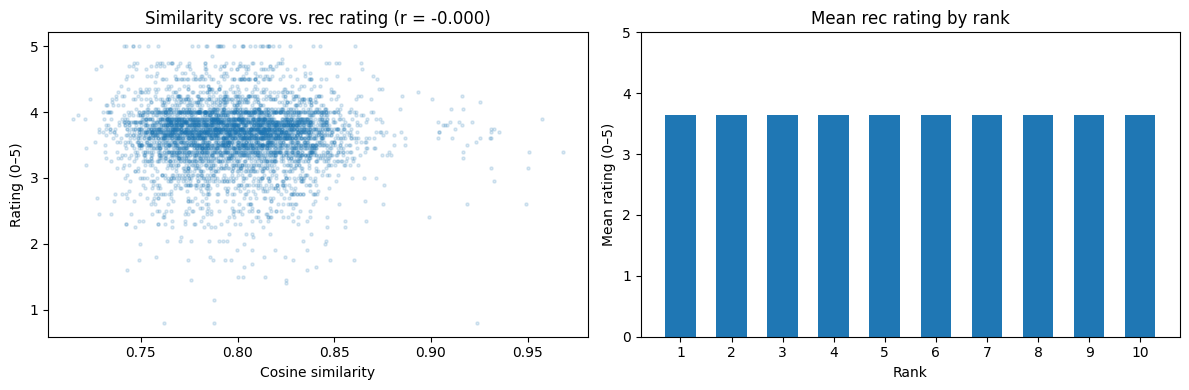

In [ ]:
# EDA Part 4: does higher similarity correlate with higher-rated recommendations?

rec_meta = (
    df[df["dataset"] == "pitchfork"][["review_id", "rating"]]
    .rename(columns={"review_id": "rec_review_id", "rating": "rec_rating"})
)
df_recs_full = df_recs.merge(rec_meta, on="rec_review_id", how="left")

valid = df_recs_full.dropna(subset=["rec_rating", "rec_score"])
corr  = valid["rec_score"].corr(valid["rec_rating"])
rank_ratings = df_recs_full.groupby("rank")["rec_rating"].mean()

print("RATING BIAS")
print(f"\n  Correlation (similarity score vs. rec rating): {corr:.4f}")
print(f"\n  Mean rec rating by rank:")
for r, m in rank_ratings.items():
    print(f"    Rank {r:>2}: {m:.3f}")

sample = valid.sample(min(5000, len(valid)), random_state=42)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.scatter(sample["rec_score"], sample["rec_rating"], alpha=0.15, s=5)
ax1.set_title(f"Similarity score vs. rec rating (r = {corr:.3f})")
ax1.set_xlabel("Cosine similarity")
ax1.set_ylabel("Rating (0–5)")

ax2.bar(rank_ratings.index, rank_ratings.values, width=0.6)
ax2.set_title("Mean rec rating by rank")
ax2.set_xlabel("Rank")
ax2.set_ylabel("Mean rating (0–5)")
ax2.set_xticks(range(1, 11))
ax2.set_ylim(0, 5)

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Colab Notebooks/eda_4_rating_bias.png", dpi=100)
plt.show()
plt.close()
del df_recs_full, valid, sample


Cross-genre recommendation rates (% of each query genre's top-10)

Query →              Rock  Electro      Rap  Experim  Pop/R&B    Metal  Folk/Co     Jazz
────────────────────────────────────────────────────────────────────────────────────────
Rock               64.8←    13.4      4.2      6.7      4.2      3.1      3.0      0.6  
Electronic         42.7     39.2←     3.3      6.9      4.2      1.8      1.0      0.8  
Rap                31.0      6.4     54.3←     1.6      5.0      1.2      0.1      0.5  
Experimental       54.3     17.3      1.0     17.7←     2.4      4.1      1.6      1.7  
Pop/R&B            51.9     17.6      9.0      3.9     13.7←     0.9      2.3      0.6  
Metal              46.8      7.4      2.2      7.3      1.0     33.5←     0.6      1.0  
Folk/Country       65.3      7.7      0.7      6.3      3.4      1.8     14.4←     0.5  
Jazz               41.6     15.3      3.6     11.6      3.3      5.4      2.0     17.3← 

← = within-genre recommendations

Within-g

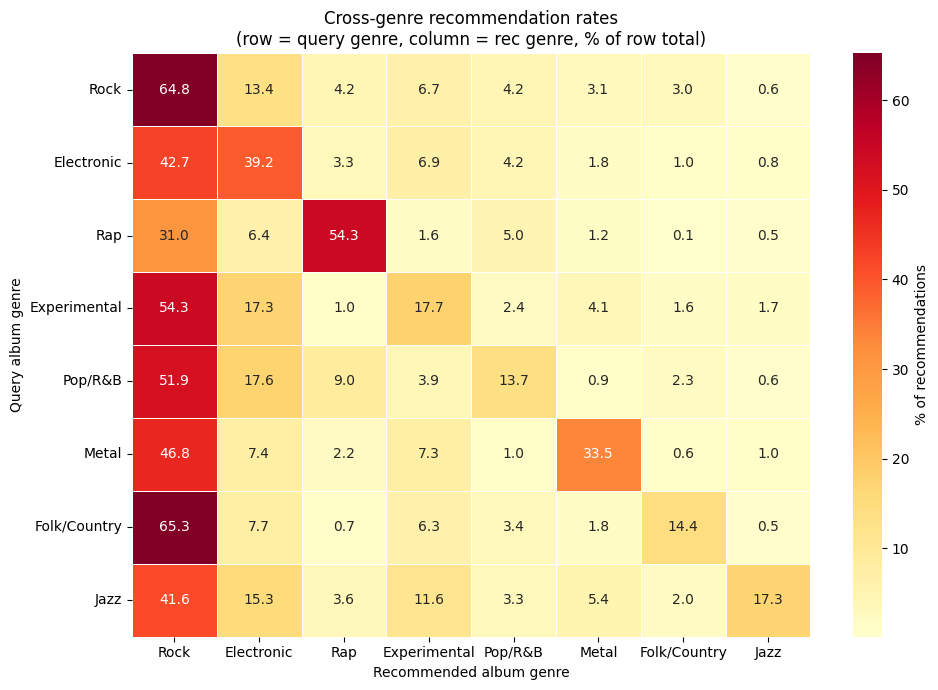

In [ ]:
# EDA Part 5a: cross-genre recommendation rate.
# For each query album's genre, shows what % of its top-10 recommendations
# come from each genre. Directly tests the bridging capital thesis.

import seaborn as sns

# Build genre lookup as a dict — avoids duplicate index error
genre_lookup = (
    df[df["dataset"] == "pitchfork"]
    .drop_duplicates(subset=["review_id"])
    .set_index("review_id")["genre"]
    .to_dict()
)

df_recs["query_genre"] = df_recs["query_review_id"].map(genre_lookup)
df_recs["rec_genre"]   = df_recs["rec_review_id"].map(genre_lookup)

# Take primary genre only (first in comma-separated list)
def primary_genre(g):
    if pd.isna(g):
        return None
    return g.split(",")[0].strip()

df_recs["query_genre_primary"] = df_recs["query_genre"].apply(primary_genre)
df_recs["rec_genre_primary"]   = df_recs["rec_genre"].apply(primary_genre)

MAIN_GENRES = ["Rock", "Electronic", "Rap", "Experimental",
               "Pop/R&B", "Metal", "Folk/Country", "Jazz"]

df_cross = df_recs[
    df_recs["query_genre_primary"].isin(MAIN_GENRES) &
    df_recs["rec_genre_primary"].isin(MAIN_GENRES)
].copy()

# Row-normalized cross-tab: % of each query genre's recommendations by rec genre
crosstab = pd.crosstab(
    df_cross["query_genre_primary"],
    df_cross["rec_genre_primary"],
    normalize="index"
) * 100
crosstab = crosstab.reindex(index=MAIN_GENRES, columns=MAIN_GENRES, fill_value=0)

# Print table
print("Cross-genre recommendation rates (% of each query genre's top-10)\n")
header = f"{'Query →':<16}" + "".join(f"{g[:7]:>9}" for g in MAIN_GENRES)
print(header)
print("─" * len(header))
for qg in MAIN_GENRES:
    row = f"{qg:<16}"
    for rg in MAIN_GENRES:
        val = crosstab.loc[qg, rg] if qg in crosstab.index else 0
        marker = "←" if qg == rg else " "
        row += f"{val:>7.1f}{marker} "
    print(row)
print("\n← = within-genre recommendations")

print(f"\nWithin-genre recommendation rate by genre:")
for g in MAIN_GENRES:
    if g in crosstab.index:
        print(f"  {g:<15} {crosstab.loc[g, g]:.1f}%")

# Heatmap
fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(
    crosstab, annot=True, fmt=".1f", cmap="YlOrRd",
    linewidths=0.5, ax=ax, cbar_kws={"label": "% of recommendations"}
)
ax.set_title("Cross-genre recommendation rates\n(row = query genre, column = rec genre, % of row total)")
ax.set_xlabel("Recommended album genre")
ax.set_ylabel("Query album genre")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Colab Notebooks/eda_5_cross_genre.png", dpi=100)
plt.show()
plt.close()

df_recs.drop(columns=["query_genre", "rec_genre",
                       "query_genre_primary", "rec_genre_primary"], inplace=True)


Corpus base rates (% of Pitchfork albums per primary genre):
  Rock            39.5%
  Electronic      21.8%
  Rap             10.2%
  Experimental    9.8%
  Pop/R&B         8.3%
  Metal           4.1%
  Folk/Country    4.4%
  Jazz            1.8%

Corpus-adjusted recommendation ratios (observed % ÷ base rate %)

Query →              Rock  Electro      Rap  Experim  Pop/R&B    Metal  Folk/Co     Jazz
────────────────────────────────────────────────────────────────────────────────────────
Rock               1.64←    0.61     0.41     0.68     0.51     0.76     0.68     0.35  
Electronic         1.08     1.80←    0.33     0.70     0.51     0.45     0.23     0.45  
Rap                0.78     0.29     5.31←    0.16     0.60     0.29     0.03     0.27  
Experimental       1.37     0.79     0.10     1.80←    0.28     1.00     0.36     0.94  
Pop/R&B            1.31     0.81     0.88     0.40     1.64←    0.21     0.52     0.34  
Metal              1.18     0.34     0.22     0.75     0.12   

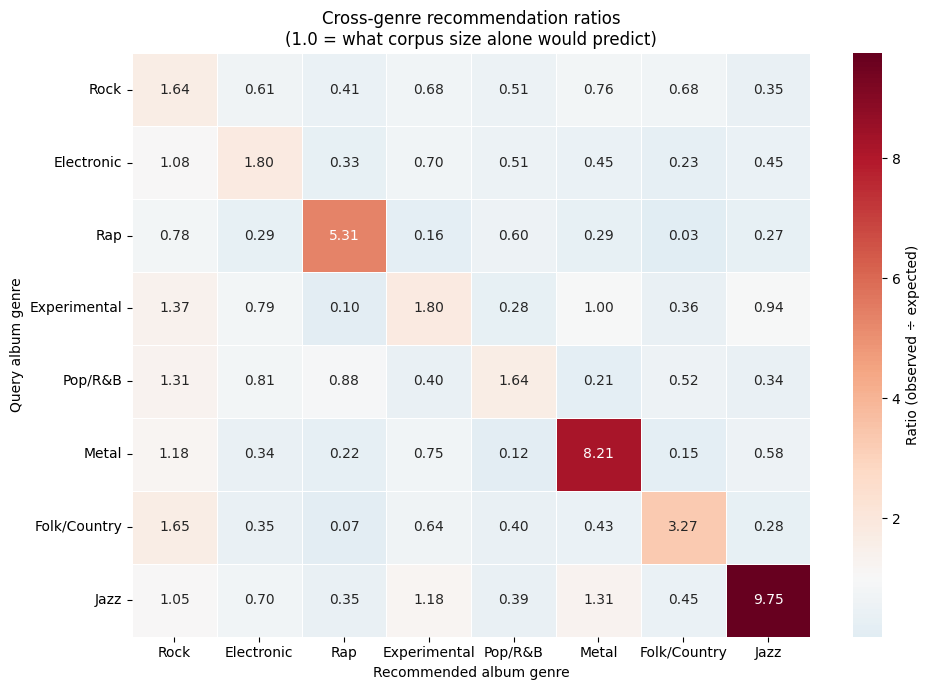

In [ ]:
# EDA Part 5b: corpus-adjusted cross-genre rates.
# Divides observed recommendation rates by the corpus base rate for each genre.
# Ratio > 1.0 = recommended more than chance; < 1.0 = recommended less than chance.
# Separates genuine semantic signal from corpus size effects.

MAIN_GENRES = ["Rock", "Electronic", "Rap", "Experimental",
               "Pop/R&B", "Metal", "Folk/Country", "Jazz"]

def primary_genre(g):
    if pd.isna(g):
        return None
    return g.split(",")[0].strip()

# Corpus base rate: % of Pitchfork albums in each primary genre
pf_primary = df[df["dataset"] == "pitchfork"]["genre"].apply(primary_genre)
pf_main    = pf_primary[pf_primary.isin(MAIN_GENRES)]
base_rates = pf_main.value_counts(normalize=True) * 100
base_rates = base_rates.reindex(MAIN_GENRES)

print("Corpus base rates (% of Pitchfork albums per primary genre):")
for g, r in base_rates.items():
    print(f"  {g:<15} {r:.1f}%")

# Divide each column of the observed crosstab by that genre's base rate
ratio_table = crosstab.copy()
for genre in MAIN_GENRES:
    if genre in ratio_table.columns and genre in base_rates.index:
        ratio_table[genre] = ratio_table[genre] / base_rates[genre]

ratio_table = ratio_table.reindex(index=MAIN_GENRES, columns=MAIN_GENRES, fill_value=0)

# Print ratio table
print(f"\nCorpus-adjusted recommendation ratios (observed % ÷ base rate %)\n")
header = f"{'Query →':<16}" + "".join(f"{g[:7]:>9}" for g in MAIN_GENRES)
print(header)
print("─" * len(header))
for qg in MAIN_GENRES:
    row = f"{qg:<16}"
    for rg in MAIN_GENRES:
        val    = ratio_table.loc[qg, rg] if qg in ratio_table.index else 0
        marker = "←" if qg == rg else " "
        row   += f"{val:>7.2f}{marker} "
    print(row)
print("\n← = within-genre | >1.0 = above chance | <1.0 = below chance")

# Heatmap with diverging colormap centered at 1.0
import seaborn as sns

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(
    ratio_table, annot=True, fmt=".2f", cmap="RdBu_r",
    center=1.0, linewidths=0.5, ax=ax,
    cbar_kws={"label": "Ratio (observed ÷ expected)"}
)
ax.set_title("Cross-genre recommendation ratios\n(1.0 = what corpus size alone would predict)")
ax.set_xlabel("Recommended album genre")
ax.set_ylabel("Query album genre")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Colab Notebooks/eda_5b_adjusted_cross_genre.png", dpi=100)
plt.show()
plt.close()


In [ ]:
# EDA Part 6: read the actual review text of the top hub albums.
# Determines whether hubs are generic reviews that match everything,
# or genuinely rich reviews that happen to be broadly similar.

DRIVE_DIR = "/content/drive/MyDrive/Colab Notebooks"

# Get top 5 hub albums with their review IDs
hub_df = (
    df_recs.groupby(["rec_review_id", "rec_artist", "rec_album"])
    .size()
    .reset_index(name="rec_count")
    .sort_values("rec_count", ascending=False)
    .head(5)
)

# Load only review text for those IDs — avoids loading full corpus into RAM
hub_ids   = hub_df["rec_review_id"].tolist()
df_text   = pd.read_parquet(
    f"{DRIVE_DIR}/merged_dataset_masked.parquet",
    columns=["review_id", "cleaned_text"]
)
text_lookup = df_text[df_text["review_id"].isin(hub_ids)].set_index("review_id")["cleaned_text"]
del df_text

print("TOP HUB ALBUMS — REVIEW TEXT SPOT-CHECK\n")
for _, row in hub_df.iterrows():
    text = text_lookup.get(row["rec_review_id"], "[not found]")
    print(f"{'='*70}")
    print(f"{row['rec_artist']} — {row['rec_album']}")
    print(f"Recommended {row['rec_count']:,} times")
    print(f"{'─'*70}")
    print(text[:600])
    print("...\n")


TOP HUB ALBUMS — REVIEW TEXT SPOT-CHECK

These Are Powers — Terrific Seasons
Recommended 687 times
──────────────────────────────────────────────────────────────────────
One should be rightly suspicious of any band that names its own genre. These Are Powers' dubbed their sound "ghost-punk," and more than a few rock chroniclers have eaten it right up. But to be fair, there's something to the name. These Are Powers' late 2007 debut Terrific Seasons is propelled by the energy and anarchy of punk, to be sure, but there's something more mysterious lurking beneath the surface. Guitars emulate warping sheets of metal, and drums and vocals alike sound like they're bouncing off the walls of a cavernous abandoned warehouse. Couple these opposite poles of aggression and 
...

The Music — The Music
Recommended 572 times
──────────────────────────────────────────────────────────────────────
If nothing else, The Music make a great first impression. Putting their disc in and cranking the volume, I wa

RECIPROCITY

  Overall rate: 46.5%
  (106,027 of 228,100 pairs are mutually recommended)

  Rate by rank:
    Rank  1: 67.2%
    Rank  2: 56.6%
    Rank  3: 51.1%
    Rank  4: 46.7%
    Rank  5: 44.4%
    Rank  6: 42.1%
    Rank  7: 41.1%
    Rank  8: 39.3%
    Rank  9: 38.7%
    Rank 10: 37.6%


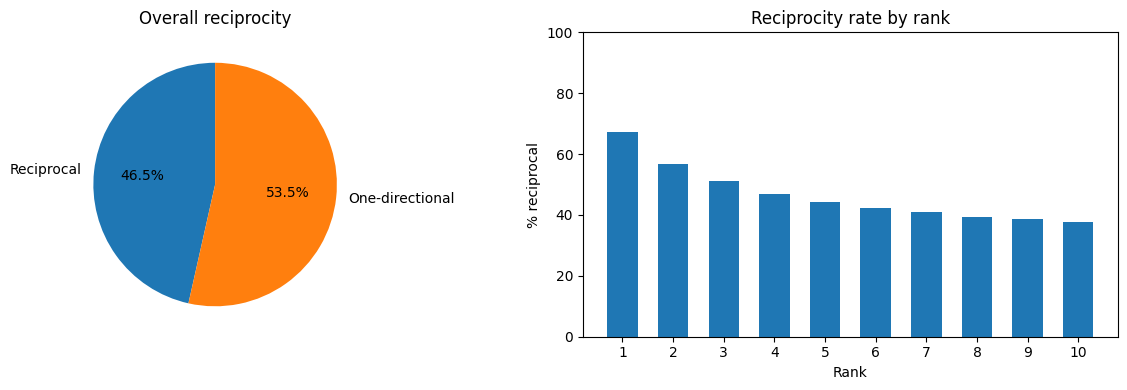

In [ ]:
# EDA Part 7: reciprocity — if album A recommends album B, does B recommend A?
# High reciprocity = tight mutual clusters.
# Low reciprocity = asymmetric, discovery-oriented recommendations.

# Build set of all (query, rec) pairs for O(1) lookup
all_pairs = set(zip(df_recs["query_review_id"], df_recs["rec_review_id"]))

# Check whether the reverse of each pair also exists
df_recs["is_reciprocal"] = [
    (r, q) in all_pairs
    for q, r in zip(df_recs["query_review_id"], df_recs["rec_review_id"])
]

overall_rate = df_recs["is_reciprocal"].mean() * 100
print("RECIPROCITY\n")
print(f"  Overall rate: {overall_rate:.1f}%")
print(f"  ({df_recs['is_reciprocal'].sum():,} of {len(df_recs):,} pairs are mutually recommended)\n")

rank_recip = df_recs.groupby("rank")["is_reciprocal"].mean() * 100
print("  Rate by rank:")
for r, rate in rank_recip.items():
    print(f"    Rank {r:>2}: {rate:.1f}%")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.pie(
    [overall_rate, 100 - overall_rate],
    labels=["Reciprocal", "One-directional"],
    autopct="%1.1f%%",
    startangle=90
)
ax1.set_title("Overall reciprocity")

ax2.bar(rank_recip.index, rank_recip.values, width=0.6)
ax2.set_title("Reciprocity rate by rank")
ax2.set_xlabel("Rank")
ax2.set_ylabel("% reciprocal")
ax2.set_xticks(range(1, 11))
ax2.set_ylim(0, 100)

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Colab Notebooks/eda_7_reciprocity.png", dpi=100)
plt.show()
plt.close()

df_recs.drop(columns=["is_reciprocal"], inplace=True)
